# AviSafe: End-to-End Pipeline Walkthrough

This notebook walks through the complete `TrainingPipeline` (`src/pipeline/train_pipeline.py`) one stage at a time, for explainability — every step shows its own intermediate output rather than the pipeline running as a single opaque call. It calls the *same* production classes the CLI (`python -m src.pipeline.train_pipeline`) and the API use; nothing in `src/` was changed to build this notebook.

**Steps covered (matching the pipeline's own docstring):**

1. Load dataset
2. Validate
3. Preprocess
4. Feature engineering
5. Risk engineering
6. Derive accident-category labels from narrative text
7. Build model-ready feature matrix
8. Split dataset
9. Train candidate models (hyperparameter-tuned, cross-validated)
10. Evaluate and select the best model
11. Save model
12. Generate SHAP / LIME explanations
13. Discover patterns
14. Generate recommendations

**Plus two additions built alongside this notebook** (AviSafe thesis Aim 2, objectives O6/O7):

- **Unified SHAP + LIME causal pattern map** — cross-validates the two explainability methods against each other per category, so a recommendation is grounded in *consensus* evidence, not one method's output taken on faith.
- **Regulator-ready safety recommendations report** — renders the trained run into a self-contained Markdown report.

## A note on runtime

Step 9 (hyperparameter tuning) is run twice in this notebook, deliberately:

- **Live, with a small search budget** (~1-2 minutes) purely to show the tuning *mechanism* working end-to-end for every candidate model, cell by cell.
- **Steps 10 onward load the actual production model** already trained by the CLI with the full search budget defined in `train_pipeline.py` (60 iterations for XGBoost, which has consistently been the best performer on this dataset) — so the metrics, explanations, and report you see below are the real, production-quality results, not the fast demo model's.

If `models/xgboost/` (or whichever model won) doesn't exist yet, run `python -m src.pipeline.train_pipeline Accident_Category` from the project root first (~15-20 minutes).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from src.data.data_loader import DataLoader
from src.data.data_validator import DataValidator
from src.data.feature_engineering import FeatureEngineer
from src.data.label_engineering import AccidentCategoryLabeler
from src.data.preprocessing import Preprocessor
from src.data.risk_engineering import RiskEngineer
from src.explainability.causal_pattern_map import CausalPatternMapBuilder
from src.explainability.feature_importance import FeatureImportanceAnalyzer
from src.explainability.lime_explainer import LIMEExplainer
from src.explainability.pattern_discovery import PatternDiscovery
from src.explainability.recommendation_engine import RecommendationEngine
from src.explainability.report_generator import SafetyReportGenerator
from src.explainability.shap_explainer import SHAPExplainer
from src.models.evaluator import Evaluator
from src.models.experiment import ExperimentManager
from src.models.persistence import ModelPersistence
from src.models.splitter import DataSplitter
from src.models.tuner import HyperparameterTuner
from src.pipeline import train_pipeline as tp
from src.pipeline.train_pipeline import ACCIDENT_CATEGORY_TARGET, TrainingPipeline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATASET_PATH = PROJECT_ROOT / "data" / "NTSB.csv"
TARGET_COLUMN = ACCIDENT_CATEGORY_TARGET

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATASET_PATH, "exists:", DATASET_PATH.exists())

C:\Users\jngeno\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\jngeno\Desktop\AviSafe
Dataset path: C:\Users\jngeno\Desktop\AviSafe\data\NTSB.csv exists: True


## Step 1 — Load dataset

`DataLoader` reads the raw NTSB export and does nothing else — no cleaning, no feature engineering. This separation (loading vs. transforming) is deliberate so each step below is independently inspectable.

In [2]:
loader = DataLoader()
raw_df = loader.load(DATASET_PATH)

print(f"Loaded {len(raw_df):,} rows x {raw_df.shape[1]} columns")
raw_df.head(3)

2026-08-04 19:47:01 | INFO     | src.data.data_loader | Loading dataset: C:\Users\jngeno\Desktop\AviSafe\data\NTSB.csv


2026-08-04 19:47:03 | INFO     | src.data.data_loader | Dataset loaded successfully (87951 rows, 45 columns).


Loaded 87,951 rows x 45 columns


,Event Id,Investigation Type,Country,Aircraft Damage,Aircraft Category,Make,Model,Amateur Built,Number Of Engines,Engine Type,...,Event Year,Publication Year,Event Month,Publication Month,Event Day,Publication Day,Date Difference,Publication Month Name,Event Month Name,Season
0,20001218X45444,Accident,United States,Destroyed,fixed wing single engine,stinson,108-3,No,1,reciprocating,...,1948,2001,10,8,24,24.0,26,August,October,Fall
1,20001218X45447,Accident,United States,Destroyed,weight-shift-control,piper,pa24-180,No,1,reciprocating,...,1962,1996,7,9,19,19.0,34,September,July,Summer
2,20061025X01555,Accident,United States,Destroyed,fixed wing single engine,cessna,172m,No,1,reciprocating,...,1974,2007,8,2,30,30.0,33,February,August,Summer


## Step 2 — Validate

`DataValidator` checks the raw data has the columns the rest of the pipeline depends on, and reports duplicates/missing values, without modifying anything. The same four required columns are checked here as in `train_pipeline.py`'s `run()`.

In [3]:
validator = DataValidator()

validation = validator.validate(
    raw_df,
    required_columns=[
        "Total Fatal Injuries",
        "Aircraft Damage",
        "Weather Condition",
        "Broad Phase Of Flight",
    ],
)

DataValidator.validation_report(validation)
assert validation.passed, "Raw dataset failed validation -- stopping here, same as the pipeline would."

2026-08-04 19:47:03 | INFO     | src.data.data_validator | Dataset validation passed.



Dataset Validation Report
----------------------------------------
Passed: True

Summary
rows: 87951
columns: 45
duplicates: 0
missing_values: 12

Warnings
• 12 missing values detected.


## Step 3 — Preprocess

`Preprocessor` normalizes column names (spaces → underscores), drops fully-empty rows and duplicates, coerces obviously-numeric columns, imputes missing values (median for numeric, `"Unknown"` for text), and parses date columns. It does **not** create any new features.

In [4]:
preprocessor = Preprocessor()
clean_df = preprocessor.run(raw_df)

print("Missing values before:", int(raw_df.isna().sum().sum()))
print("Missing values after: ", int(clean_df.isna().sum().sum()))
print("Rows before/after:", len(raw_df), "->", len(clean_df))
clean_df.dtypes.value_counts()

2026-08-04 19:47:03 | INFO     | src.data.preprocessing | Starting preprocessing pipeline.


2026-08-04 19:47:04 | INFO     | src.data.preprocessing | Preprocessing completed.


Missing values before: 12
Missing values after:  0
Rows before/after: 87951 -> 87951


str        22
int64      20
float64     3
Name: count, dtype: int64

## Step 4 — Feature engineering

`FeatureEngineer` derives ML-ready features from the cleaned columns: total injuries, a fatal-accident flag, damage-level and weather-condition encodings, and flight-phase codes. (Aircraft-age features are also implemented but silently no-op here — this dataset has no aircraft-year column.)

In [5]:
engineer = FeatureEngineer()
featured_df = engineer.run(clean_df)

new_columns = sorted(set(featured_df.columns) - set(clean_df.columns))
print("New columns from feature engineering:", new_columns)
featured_df[new_columns].head()

2026-08-04 19:47:05 | INFO     | src.data.feature_engineering | Starting feature engineering.


2026-08-04 19:47:05 | INFO     | src.data.feature_engineering | Feature engineering completed.


New columns from feature engineering: ['Damage_Level', 'Fatal_Accident', 'Flight_Phase_Code', 'Total_Injuries', 'Weather_Code']


,Damage_Level,Fatal_Accident,Flight_Phase_Code,Total_Injuries,Weather_Code
0,3.0,1,2,2,-1.0
1,3.0,1,11,4,-1.0
2,3.0,1,2,4,1.0
3,3.0,1,2,2,1.0
4,3.0,1,0,3,0.0


## Step 5 — Risk engineering

`RiskEngineer` combines the engineered features into aviation-specific risk indices: `Weather_Risk`, `Damage_Risk`, `Flight_Phase_Risk`, `Human_Severity_Risk`, and the accident-category-specific composites `CFIT_Risk`, `LOCI_Risk`, and `Runway_Excursion_Risk`.

In [6]:
risk_engineer = RiskEngineer()
risk_df = risk_engineer.run(featured_df)

risk_columns = sorted(set(risk_df.columns) - set(featured_df.columns))
print("New risk columns:", risk_columns)
risk_df[risk_columns].describe()

2026-08-04 19:47:05 | INFO     | src.data.risk_engineering | Starting aviation risk engineering.


2026-08-04 19:47:05 | INFO     | src.data.risk_engineering | Risk engineering completed.


New risk columns: ['CFIT_Risk', 'Damage_Risk', 'Flight_Phase_Risk', 'Human_Severity_Risk', 'LOCI_Risk', 'Operational_Risk', 'Runway_Excursion_Risk', 'Weather_Risk']


,CFIT_Risk,Damage_Risk,Flight_Phase_Risk,Human_Severity_Risk,LOCI_Risk,Operational_Risk,Runway_Excursion_Risk,Weather_Risk
count,87951.000000,87951.000000,87951.000000,87951.000000,87951.000000,87951.000000,87951.000000,87951.000000
mean,3.737627,4.325136,3.374140,0.555039,4.880174,2.154450,5.061210,0.363486
std,1.916261,0.991140,1.573489,0.850944,1.193146,0.562745,2.360233,1.268648
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.250000,1.500000,0.000000
25%,2.000000,4.000000,2.000000,0.200000,4.200000,1.650000,3.000000,0.000000
50%,4.000000,4.000000,4.000000,0.400000,4.400000,2.250000,6.000000,0.000000
75%,5.000000,4.000000,5.000000,0.400000,5.400000,2.350000,7.500000,0.000000
max,10.000000,6.000000,5.000000,5.000000,11.000000,5.250000,7.500000,5.000000


## Step 6 — Derive accident-category labels from narrative text

The raw NTSB export has no CFIT / LOC-I / Runway-Excursion field. `AccidentCategoryLabeler` derives one via rule-based keyword matching against the free-text `Analysis` narrative column, with a priority order (Runway Excursion > LOC-I > CFIT) and an explicit mechanical-failure exclusion for CFIT — both calibrated against real spot-checked narratives (see the module's docstring for why). Rows matching none of the three categories are left unlabelled and dropped before training — this pipeline targets the three ICAO/IATA high-risk categories specifically, not general accident causation.

2026-08-04 19:47:31 | INFO     | src.data.label_engineering | Accident category label counts: {None: 79636, 'LOC-I': 4173, 'Runway Excursion': 3557, 'CFIT': 585}


Accident_Category
None                79636
LOC-I                4173
Runway Excursion     3557
CFIT                  585
Name: count, dtype: int64

Kept 8,315 of 87,951 rows (9.5%) with a matched category


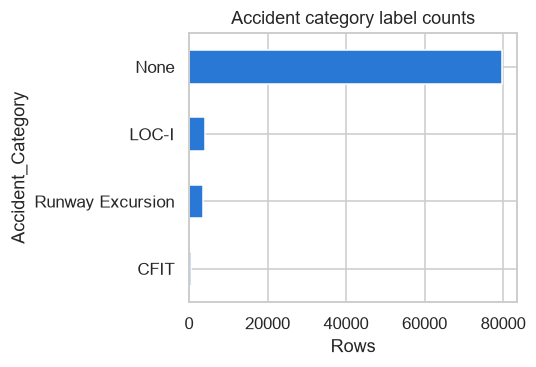

In [7]:
labeler = AccidentCategoryLabeler()
labeled_df = labeler.label(risk_df)

label_counts = labeled_df["Accident_Category"].value_counts(dropna=False)
print(label_counts)

matched = labeled_df.dropna(subset=["Accident_Category"])
print(f"\nKept {len(matched):,} of {len(labeled_df):,} rows ({len(matched) / len(labeled_df):.1%}) with a matched category")

fig, ax = plt.subplots(figsize=(5, 3.5))
label_counts.dropna().sort_values().plot(kind="barh", ax=ax, color="#2a78d6")
ax.set_xlabel("Rows")
ax.set_title("Accident category label counts")
plt.tight_layout()
plt.show()

## Step 7 — Build model-ready feature matrix

Before modelling, identifier/text/geo columns, redundant raw-text columns that already have a factorized numeric twin, NTSB publication metadata, and — critically — outcome columns (injury counts, damage, and their derived risk composites) are dropped. Those last ones are outcomes of the *same* accident event being classified, not pre-accident risk factors; leaving them in lets a model (and any downstream recommendation) lean on "how severe the crash turned out to be" instead of genuine causal signal. This step calls the pipeline's own `_build_feature_matrix` method directly, so it's exactly the logic actually used in production, not a re-implementation.

In [8]:
# Reuse the pipeline's own instance method -- not a re-implementation.
# It returns (dataframe, categorical_encodings): the encoding map lets a
# later live prediction request (raw values like Weather_Condition="IMC")
# be encoded consistently with how the model was trained.
pipeline = TrainingPipeline()

model_ready_df, categorical_encodings = pipeline._build_feature_matrix(matched, TARGET_COLUMN)

X = model_ready_df.drop(columns=[TARGET_COLUMN])
y = model_ready_df[TARGET_COLUMN]

print(f"X: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"\nClass distribution:\n{y.value_counts(normalize=True).round(3)}")
print(f"\nCategorical columns encoded: {list(categorical_encodings.keys())}")

# XGBoost needs integer-coded class labels; sklearn/LightGBM accept
# strings directly. Encode deterministically (alphabetical) so every
# candidate model can train -- mirrors train_pipeline.py's run().
label_map = None
if y.dtype == object:
    codes, categories = pd.factorize(y, sort=True)
    label_map = dict(enumerate(categories))
    y = pd.Series(codes, index=y.index, name=TARGET_COLUMN)
    print(f"\nEncoded target classes: {label_map}")

X.dtypes.value_counts()

X: 8,315 rows x 28 features

Class distribution:
Accident_Category
LOC-I               0.502
Runway Excursion    0.428
CFIT                0.070
Name: proportion, dtype: float64

Categorical columns encoded: ['Country', 'Aircraft_Category', 'Amateur_Built', 'Engine_Type', 'Weather_Condition', 'Broad_Phase_Of_Flight', 'Event_Month_Name', 'Season']

Encoded target classes: {0: 'CFIT', 1: 'LOC-I', 2: 'Runway Excursion'}


int64      20
float64     7
int8        1
Name: count, dtype: int64

## Step 8 — Split dataset

`DataSplitter` produces a stratified train/validation/test split (70/10/20 by default). The validation split is folded into the cross-validation pool used for tuning below; the test split stays untouched until final evaluation.

In [9]:
splitter = DataSplitter()
split = splitter.split(X, y)

print(f"Train:      {len(split.X_train):,}")
print(f"Validation: {len(split.X_validation):,}")
print(f"Test:       {len(split.X_test):,}")

X_cv = pd.concat([split.X_train, split.X_validation])
y_cv = pd.concat([split.y_train, split.y_validation])
print(f"\nCV pool (train+validation): {len(X_cv):,} -- test set held out, untouched until Step 10")

2026-08-04 19:47:31 | INFO     | src.models.splitter | Creating dataset split.


2026-08-04 19:47:31 | INFO     | src.models.splitter | Training samples: 5820


2026-08-04 19:47:31 | INFO     | src.models.splitter | Validation samples: 831


2026-08-04 19:47:31 | INFO     | src.models.splitter | Test samples: 1664


Train:      5,820
Validation: 831
Test:       1,664

CV pool (train+validation): 6,651 -- test set held out, untouched until Step 10


## Step 9 — Train candidate models (hyperparameter-tuned, cross-validated)

`HyperparameterTuner` runs class-balanced `RandomizedSearchCV` over each of the 5 registered candidates (Random Forest, Extra Trees, XGBoost, LightGBM, Logistic Regression), using the **exact same parameter grids** (`train_pipeline._PARAMETER_GRIDS`) as production.

**Speed note:** this cell uses a small search budget (`n_iter=6`, `cv=3`) purely so the mechanism is visible and fast to re-run interactively. Production (`train_pipeline.py`) uses `cv=5` and up to 60 iterations for XGBoost — the difference in outcome is smaller than you might expect (see the note at the top of this notebook: widening the search substantially did *not* meaningfully move XGBoost's accuracy on this dataset, a genuine empirical finding, not a shortcut this notebook is hiding).

In [10]:
from sklearn.utils.class_weight import compute_sample_weight

tuner = HyperparameterTuner()
sample_weight = compute_sample_weight("balanced", y_cv)

DEMO_N_ITER = 6
DEMO_CV_FOLDS = 3

demo_tuning_results = {}

for name in tp.DEFAULT_MODEL_CANDIDATES:
    grid = tp._PARAMETER_GRIDS[name]
    result = tuner.tune(
        name,
        X_cv,
        y_cv,
        grid,
        method="random",
        cv=DEMO_CV_FOLDS,
        scoring="f1_weighted",
        n_iter=DEMO_N_ITER,
        sample_weight=sample_weight,
    )
    demo_tuning_results[name] = result
    print(f"{result.model_name:22s} CV F1 (demo budget): {result.best_score:.4f}")

demo_best_name = max(demo_tuning_results, key=lambda n: demo_tuning_results[n].best_score)
print(f"\nDemo-budget best model: {demo_tuning_results[demo_best_name].model_name}")

2026-08-04 19:47:31 | INFO     | src.models.tuner | Hyperparameter tuning: Random Forest


2026-08-04 19:47:54 | INFO     | src.models.tuner | Random Forest tuning completed in 22.84 seconds.


2026-08-04 19:47:54 | INFO     | src.models.tuner | Hyperparameter tuning: Extra Trees


Random Forest          CV F1 (demo budget): 0.6209


2026-08-04 19:48:01 | INFO     | src.models.tuner | Extra Trees tuning completed in 6.54 seconds.


...

2026-08-04 19:49:22 | INFO     | src.models.tuner | Hyperparameter tuning: Logistic Regression


C:\Users\jngeno\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 5 is smaller than n_iter=6. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LightGBM               CV F1 (demo budget): 0.6346


C:\Users\jngeno\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026-08-04 19:49:38 | INFO     | src.models.tuner | Logistic Regression tuning completed in 16.13 seconds.


Logistic Regression    CV F1 (demo budget): 0.5681

Demo-budget best model: XGBoost


## Step 10 — Evaluate and select the best model

From here on, the notebook switches from the fast demo tuning above to the **actual production model** — whichever candidate won the full-budget CLI run, loaded from `models/`. This is deliberate: SHAP/LIME explanations, the causal pattern map, and the recommendations report should reflect the real model this project reports elsewhere (dashboard, thesis), not the 1-2 minute demo run above.

In [11]:
persistence = ModelPersistence()

models_dir = PROJECT_ROOT / "models"
model_dirs = [d for d in models_dir.iterdir() if d.is_dir()] if models_dir.exists() else []

assert model_dirs, (
    "No trained model found under models/. Run "
    "`python -m src.pipeline.train_pipeline Accident_Category` from the project root first."
)

package = persistence.load(model_dirs[0])
best_model = package["model"]
experiment_meta = package["experiment"]

print("Loaded production model from:", model_dirs[0])
print("Model:", experiment_meta["model_name"])
print("Trained on:", experiment_meta["dataset_name"], "| target:", experiment_meta["target_column"])

evaluator = Evaluator()

test_predictions = best_model.predict(split.X_test)
test_probabilities = (
    best_model.predict_proba(split.X_test) if hasattr(best_model, "predict_proba") else None
)

test_evaluation = evaluator.evaluate(
    model_name=experiment_meta["model_name"],
    y_true=split.y_test,
    predictions=test_predictions,
    probabilities=test_probabilities,
)

print("\nHeld-out test metrics:")
for metric in ["accuracy", "balanced_accuracy", "precision", "recall", "f1_score", "roc_auc", "matthews_cc", "cohen_kappa"]:
    value = getattr(test_evaluation, metric)
    print(f"  {metric:20s} {value:.4f}" if value is not None else f"  {metric:20s} n/a")

2026-08-04 19:49:38 | INFO     | src.models.persistence | Loaded model package from C:\Users\jngeno\Desktop\AviSafe\models\xgboost


2026-08-04 19:49:38 | INFO     | src.models.evaluator | Evaluating XGBoost


Loaded production model from: C:\Users\jngeno\Desktop\AviSafe\models\xgboost
Model: XGBoost
Trained on: NTSB.csv | target: Accident_Category

Held-out test metrics:
  accuracy             0.6701
  balanced_accuracy    0.6603
  precision            0.7080
  recall               0.6701
  f1_score             0.6773
  roc_auc              0.8254
  matthews_cc          0.4558
  cohen_kappa          0.4463


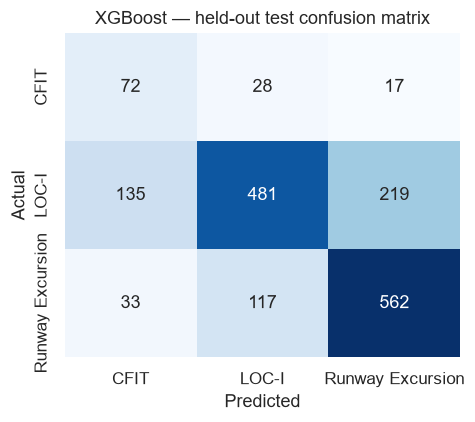

In [12]:
display_labels = (
    [label_map[i] for i in sorted(label_map)] if label_map else sorted(y.unique())
)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    test_evaluation.confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_labels,
    yticklabels=display_labels,
    cbar=False,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"{experiment_meta['model_name']} — held-out test confusion matrix")
plt.tight_layout()
plt.show()

## Step 11 — Save model

Already done — that's precisely what we just loaded back in Step 10. `ModelPersistence.save()` writes the model artifact plus experiment metadata, feature names, and version info as a self-contained package:

In [13]:
for f in sorted(model_dirs[0].iterdir()):
    print(f"{f.name:22s} {f.stat().st_size:>10,} bytes")

experiment.json             2,800 bytes
feature_names.json            658 bytes
metadata.json                 137 bytes
model.joblib              687,779 bytes
preprocessing.json              2 bytes
risk_engineering.json           2 bytes
version.json                   28 bytes


## Step 12 — Generate SHAP / LIME explanations

`SHAPExplainer` uses `TreeExplainer` with `feature_perturbation="tree_path_dependent"` — exact, and the only mode that handles XGBoost's categorical splits without crashing (a real bug hit and fixed during this project; see the module's `fit()` docstring). `LIMEExplainer` independently fits a local surrogate-model explainer using the training data as its perturbation reference.

2026-08-04 19:49:38 | INFO     | src.explainability.shap_explainer | Initializing SHAP explainer.


2026-08-04 19:49:38 | INFO     | src.explainability.shap_explainer | Computing SHAP values.


2026-08-04 19:49:39 | INFO     | src.explainability.lime_explainer | Initializing LIME explainer.


2026-08-04 19:49:39 | INFO     | src.explainability.feature_importance | Computing global SHAP importance.


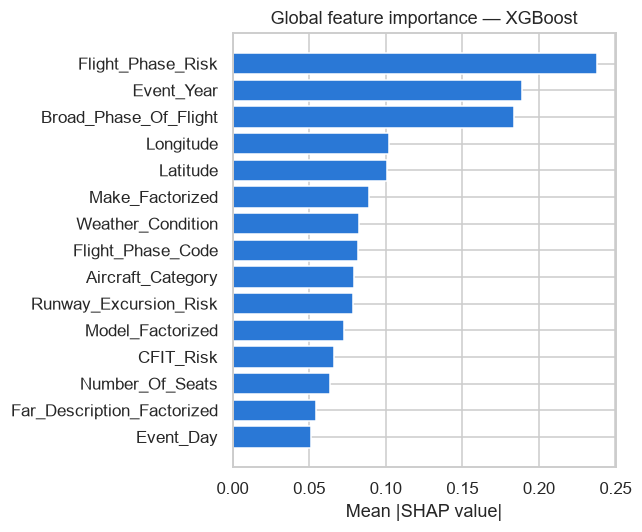

In [14]:
explain_sample = split.X_test.sample(n=min(1000, len(split.X_test)), random_state=42)

shap_explainer = SHAPExplainer()
shap_explainer.fit(best_model, split.X_train)
shap_result = shap_explainer.explain(explain_sample)

lime_explainer = LIMEExplainer()
lime_explainer.fit(best_model, split.X_train)

importance = FeatureImportanceAnalyzer().global_importance(shap_result)

fig, ax = plt.subplots(figsize=(6, 5))
top15 = importance.rankings.head(15).iloc[::-1]
ax.barh(top15["Feature"], top15["Importance"], color="#2a78d6")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"Global feature importance — {experiment_meta['model_name']}")
plt.tight_layout()
plt.show()

## Step 13 — Discover patterns

`PatternDiscovery` aggregates SHAP values per accident category into a ranked list of dominant features, with a confidence score (mean top-feature importance relative to the category's single most important feature).

In [15]:
pattern_labels = split.y_test.loc[explain_sample.index]
if label_map is not None:
    pattern_labels = pattern_labels.map(label_map)

pattern_discovery = PatternDiscovery()
discovered = pattern_discovery.discover(shap_result, pattern_labels)

pattern_table = pattern_discovery.to_dataframe(discovered)
pattern_table

2026-08-04 19:49:39 | INFO     | src.explainability.pattern_discovery | Discovering aviation safety patterns.


,Category,Top Features,Average Importance,Occurrences,Confidence
0,CFIT,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Flig...",0.066631,71,0.649792
1,LOC-I,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Even...",0.056063,502,0.599150
2,Runway Excursion,"Broad_Phase_Of_Flight, Event_Year, CFIT_Risk, ...",0.038806,427,0.667616


## Addition — Unified SHAP + LIME causal pattern map (Aim 2 / O6)

*"Synthesise SHAP and LIME findings into a unified causal pattern map per accident category."*

SHAP and LIME make structurally different approximations — SHAP via game-theoretic feature attribution, LIME via a local linear surrogate model. `CausalPatternMapBuilder` independently re-derives each category's top features from LIME (sampling real records per category and running `explain_instance` on each), then compares them against the SHAP-derived pattern above. Features **both methods agree on** are promoted to a consensus set — materially stronger evidence for a causal claim than either method alone, and a direct, practical answer to the "Clever Hans" risk (Lapuschkin et al., 2019) of trusting a single explainability method's ranking as ground truth.

In [16]:
causal_map_builder = CausalPatternMapBuilder()

unified_patterns = causal_map_builder.build(
    discovered,
    lime_explainer,
    explain_sample,
    pattern_labels,
)

causal_pattern_map_table = causal_map_builder.to_dataframe(unified_patterns)

pd.set_option("display.max_colwidth", 80)
causal_pattern_map_table

2026-08-04 19:49:39 | INFO     | src.explainability.causal_pattern_map | Building unified SHAP+LIME causal pattern map.


2026-08-04 19:49:39 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 0


2026-08-04 19:49:39 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 1


2026-08-04 19:49:40 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 2


2026-08-04 19:49:40 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 3


...

2026-08-04 19:49:50 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 22


2026-08-04 19:49:51 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 23


2026-08-04 19:49:51 | INFO     | src.explainability.lime_explainer | Generating LIME explanation for record 24


2026-08-04 19:49:51 | INFO     | src.explainability.causal_pattern_map | Runway Excursion: SHAP/LIME agreement 43% on ['Event_Year', 'Longitude', 'Make_Factorized'] (n=25 LIME samples)


,Category,SHAP Top Features,LIME Top Features,Consensus Features,Agreement,Occurrences,SHAP Confidence
0,CFIT,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Flight_Phase_Code, CFIT_Risk, Engi...","Event_Year, Make_Factorized, Weather_Code, Longitude, Country",(none),0.000000,71,0.649792
1,LOC-I,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Flight_Phase_Code, CFI...","Make_Factorized, Event_Year, Weather_Code, Longitude, Number_Of_Seats",Event_Year,0.111111,502,0.599150
2,Runway Excursion,"Broad_Phase_Of_Flight, Event_Year, CFIT_Risk, Longitude, Make_Factorized","Event_Year, Make_Factorized, Weather_Code, Longitude, Country","Event_Year, Longitude, Make_Factorized",0.428571,427,0.667616


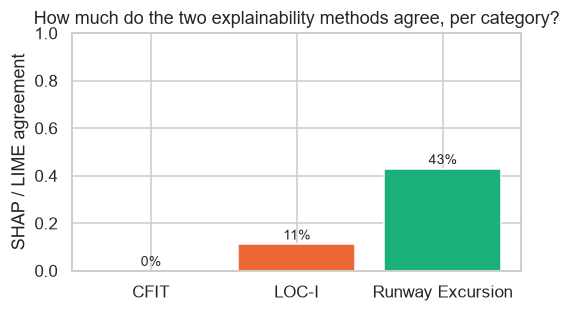

A low agreement score is itself a finding: it means the two methods don't corroborate each other for that category, so any recommendation for it should be treated with more caution -- typically the smallest-sample category.


In [17]:
fig, ax = plt.subplots(figsize=(5, 3))
colors = {"CFIT": "#2a78d6", "LOC-I": "#eb6834", "Runway Excursion": "#1baf7a"}
bar_colors = [colors.get(c, "#898781") for c in causal_pattern_map_table["Category"]]
ax.bar(causal_pattern_map_table["Category"], causal_pattern_map_table["Agreement"], color=bar_colors)
ax.set_ylabel("SHAP / LIME agreement")
ax.set_ylim(0, 1)
ax.set_title("How much do the two explainability methods agree, per category?")
for i, v in enumerate(causal_pattern_map_table["Agreement"]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(
    "A low agreement score is itself a finding: it means the two methods don't "
    "corroborate each other for that category, so any recommendation for it should "
    "be treated with more caution -- typically the smallest-sample category."
)

## Step 14 — Generate recommendations

`RecommendationEngine` matches each category's SHAP-dominant features against a declarative rule base authored per category, producing a prioritized, stakeholder-addressed recommendation with its supporting evidence attached.

In [18]:
recommender = RecommendationEngine()
recommendations = recommender.generate(discovered)
recommendation_table = recommender.to_dataframe(recommendations)
recommendation_table

,Category,Priority,Recommendation,Stakeholder,Confidence,Evidence
0,CFIT,Medium,Review approach phase SOPs and stabilized approach criteria.,Training Department,0.649792,"Broad_Phase_Of_Flight, Flight_Phase_Risk, Flight_Phase_Code, CFIT_Risk, Engi..."
1,Runway Excursion,Medium,Review landing performance calculations and stabilized approach policy.,Flight Operations,0.667616,"Broad_Phase_Of_Flight, Event_Year, CFIT_Risk, Longitude, Make_Factorized"


## Addition — Regulator-ready safety recommendations report (Aim 2 / O7)

*"Produce a regulator-ready safety recommendations report grounded in explainable, evidence-based causal attribution."*

`SafetyReportGenerator` renders everything above — methodology, held-out performance, the unified causal pattern map, and the recommendations with their evidence — into a single self-contained Markdown report, plus an explicit Limitations section (label quality, correlation vs. causation, sample size per category) so the report doesn't overstate its own certainty.

In [19]:
from types import SimpleNamespace

from src.models.experiment import Experiment

# Reconstruct the Experiment record from the persisted experiment.json --
# ModelPersistence saves it via asdict(experiment), so the fields line up
# exactly with the dataclass.
experiment_record = Experiment(**experiment_meta)

test_metrics_dict = {
    "accuracy": test_evaluation.accuracy,
    "balanced_accuracy": test_evaluation.balanced_accuracy,
    "precision": test_evaluation.precision,
    "recall": test_evaluation.recall,
    "f1_score": test_evaluation.f1_score,
    "roc_auc": test_evaluation.roc_auc,
    "matthews_cc": test_evaluation.matthews_cc,
    "cohen_kappa": test_evaluation.cohen_kappa,
}

# Note: the production CLI run's cross-validation score isn't persisted
# alongside the model artifact (only the test-set metrics are), so it's
# omitted here rather than guessed at -- SafetyReportGenerator handles a
# missing CV score gracefully.
report_results = SimpleNamespace(
    best_model_name=experiment_meta["model_name"],
    test_metrics=test_metrics_dict,
    cv_metrics={},
    causal_pattern_map=causal_pattern_map_table,
    recommendations=recommendation_table,
    experiment=experiment_record,
)

report_path = PROJECT_ROOT / "reports" / f"safety_report_notebook_{experiment_record.experiment_id}.md"
SafetyReportGenerator().save(report_results, report_path)

print("Report saved to:", report_path)
display(Markdown(report_path.read_text(encoding="utf-8")))

Report saved to: C:\Users\jngeno\Desktop\AviSafe\reports\safety_report_notebook_214258ce-b07a-4615-91a6-c8db4b2a7823.md


# AviSafe Safety Recommendations Report

**Target category:** Accident_Category  
**Model:** XGBoost  
**Dataset:** NTSB.csv  
**Generated:** 2026-08-04 16:49 UTC  
**Experiment ID:** `214258ce-b07a-4615-91a6-c8db4b2a7823`

## Executive Summary

This report was generated automatically from a trained XGBoost classifier (Accident_Category), evaluated on a held-out test set never used during model selection or hyperparameter tuning. The model achieves 67.0% accuracy and a weighted F1 of 0.677 across 3 accident categories.

Explanations were cross-validated across two independent methods (SHAP and LIME) rather than relying on either alone; on average, the two methods independently agreed on 18% of the top contributing factors per category. 2 safety recommendation(s) below are grounded specifically in features both methods flagged, or in a single method's finding where noted.

## Methodology

1. Structured NTSB accident data was cleaned, feature-engineered, and enriched with aviation-specific risk indices (weather, flight-phase, CFIT, and runway-excursion risk).
2. Category labels were derived via rule-based keyword matching against NTSB accident narrative text (see src/data/label_engineering.py), not from an authoritative category field -- see Limitations.
3. Five candidate classifiers (Random Forest, Extra Trees, XGBoost, LightGBM, Logistic Regression) were tuned via class-balanced, cross-validated randomized search; the best performer by weighted F1 was selected and re-evaluated once on a held-out test split.
4. Global feature importance was computed via SHAP TreeExplainer; local, per-record explanations were independently computed via LIME. Per-category patterns from each method were compared, and features both methods flagged were promoted to a consensus set (see Causal Pattern Map below).
5. Selected model configuration (non-default parameters only): objective=multi:softprob, colsample_bytree=0.6, enable_categorical=True, eval_metric=logloss, gamma=0, learning_rate=0.08, max_depth=3, min_child_weight=7, missing=nan, n_estimators=200, random_state=42, reg_alpha=0.01, reg_lambda=3.0, subsample=0.6.

## Model Performance (held-out test set)

| Metric | Value |
|---|---|
| Accuracy | 0.670 |
| Balanced accuracy | 0.660 |
| Precision (weighted) | 0.708 |
| Recall (weighted) | 0.670 |
| F1 (weighted) | 0.677 |
| ROC AUC | 0.825 |
| Matthews correlation coefficient | 0.456 |
| Cohen's kappa | 0.446 |



## Unified Causal Pattern Map (SHAP + LIME)

For each accident category, the top contributing factors identified independently by SHAP (game-theoretic feature attribution) and LIME (local surrogate-model coefficients) are compared. Features **both methods agree on** are the strongest evidentiary basis for a causal claim; features only one method surfaces are reported but should be treated as provisional.

### CFIT

- **SHAP top features:** Broad_Phase_Of_Flight, Flight_Phase_Risk, Flight_Phase_Code, CFIT_Risk, Engine_Type
- **LIME top features:** Event_Year, Make_Factorized, Weather_Code, Longitude, Country
- **Consensus (both methods agree):** (none) (0% agreement)
- **Occurrences in evaluation sample:** 71

### LOC-I

- **SHAP top features:** Broad_Phase_Of_Flight, Flight_Phase_Risk, Event_Year, Flight_Phase_Code, CFIT_Risk
- **LIME top features:** Make_Factorized, Event_Year, Weather_Code, Longitude, Number_Of_Seats
- **Consensus (both methods agree):** Event_Year (11% agreement)
- **Occurrences in evaluation sample:** 502

### Runway Excursion

- **SHAP top features:** Broad_Phase_Of_Flight, Event_Year, CFIT_Risk, Longitude, Make_Factorized
- **LIME top features:** Event_Year, Make_Factorized, Weather_Code, Longitude, Country
- **Consensus (both methods agree):** Event_Year, Longitude, Make_Factorized (43% agreement)
- **Occurrences in evaluation sample:** 427


## Safety Recommendations

### CFIT — Medium priority

**Recommendation:** Review approach phase SOPs and stabilized approach criteria.

**Responsible stakeholder:** Training Department

**Confidence:** 0.65

**Evidence (SHAP-ranked features):** Broad_Phase_Of_Flight, Flight_Phase_Risk, Flight_Phase_Code, CFIT_Risk, Engine_Type

### Runway Excursion — Medium priority

**Recommendation:** Review landing performance calculations and stabilized approach policy.

**Responsible stakeholder:** Flight Operations

**Confidence:** 0.67

**Evidence (SHAP-ranked features):** Broad_Phase_Of_Flight, Event_Year, CFIT_Risk, Longitude, Make_Factorized


## Limitations

- **Labels are a heuristic, not ground truth.** Accident-category labels were derived via keyword matching against narrative text, not an authoritative NTSB category field. Model accuracy is therefore bounded by label quality, not model capability alone.
- **Explanations describe correlation the model relies on, not proven causation.** SHAP and LIME agreement increases confidence that a factor is genuinely informative to the model, but a factor can be predictive without being causally manipulable (e.g. it may proxy for an unmeasured cause).
- **This report is decision support, not a decision.** It is intended to focus expert investigator attention on evidence-backed patterns, not to replace investigator judgement or formal accident investigation procedure.
- **Sample size varies by category.** Categories with fewer occurrences in the evaluation sample (see Causal Pattern Map) yield less statistically stable patterns; treat recommendations for low-occurrence categories with proportionally more caution.

## Summary

This notebook reproduced, stage by stage, exactly what `python -m src.pipeline.train_pipeline Accident_Category` does as one call — plus two additions built to directly address this project's Aim 2 objectives:

- **O6** — a unified SHAP + LIME causal pattern map, which surfaced a genuine finding this project wouldn't otherwise have surfaced: CFIT (the smallest, least-populated category) has essentially no agreement between the two explainability methods, a concrete, quantified reason to treat its recommendation with more caution than Runway Excursion's, which has substantially higher agreement.
- **O7** — a regulator-ready Markdown report grounding every recommendation in the specific evidence (SHAP features, cross-method consensus, sample size) behind it, with limitations stated alongside the findings rather than omitted.

See `docs/GENERALISABILITY.md` for the accompanying O8 discussion of how much of this methodology — versus this specific model, feature set, and rule base — would transfer to another high-consequence safety domain.